<a href="https://colab.research.google.com/github/mafedcp65-netizen/Revision-de-la-literatura/blob/main/graficas_revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install openpyxl wordcloud

In [ ]:
# @title
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

# =========================
# 0. Compatibilidad extra para columnas con mayúsculas/minúsculas
#    (esto permite que los dos últimos bloques sigan intactos)
# =========================
if not getattr(pd, "_case_insensitive_patch_articulos", False):
    _pd_series_getitem_original = pd.Series.__getitem__
    _pd_dataframe_getitem_original = pd.DataFrame.__getitem__

    _pd_read_excel_original = pd.read_excel

    def _read_excel_with_fallback(io, *args, **kwargs):
        if isinstance(io, str) and not os.path.exists(io):
            candidatos = [
                "/mnt/data/" + os.path.basename(io),
                os.path.join(os.getcwd(), os.path.basename(io))
            ]
            for alt in candidatos:
                if os.path.exists(alt):
                    io = alt
                    break
        return _pd_read_excel_original(io, *args, **kwargs)


    def _series_getitem_case_insensitive(self, key):
        try:
            return _pd_series_getitem_original(self, key)
        except KeyError:
            if isinstance(key, str):
                mapa = {str(idx).strip().lower(): idx for idx in self.index}
                alt = mapa.get(key.strip().lower())
                if alt is not None:
                    return _pd_series_getitem_original(self, alt)
            raise

    def _dataframe_getitem_case_insensitive(self, key):
        try:
            return _pd_dataframe_getitem_original(self, key)
        except KeyError:
            if isinstance(key, str):
                mapa = {str(col).strip().lower(): col for col in self.columns}
                alt = mapa.get(key.strip().lower())
                if alt is not None:
                    return _pd_dataframe_getitem_original(self, alt)
            raise

    pd.Series.__getitem__ = _series_getitem_case_insensitive
    pd.DataFrame.__getitem__ = _dataframe_getitem_case_insensitive
    pd.read_excel = _read_excel_with_fallback
    pd._case_insensitive_patch_articulos = True

# =========================
# 1. Cargar archivo
# =========================
posibles_rutas = [
    "/content/Articulos.xlsx",
    "/mnt/data/Articulos.xlsx"
]

ruta_excel = next((p for p in posibles_rutas if os.path.exists(p)), posibles_rutas[0])
hoja = "Datos"

df = pd.read_excel(ruta_excel, sheet_name=hoja)

# =========================
# 2. Estandarizar columnas y texto a minúsculas
# =========================
def normalizar_espacios(texto):
    return re.sub(r"\s+", " ", str(texto)).strip()

def limpiar_texto(x):
    if pd.isna(x):
        return np.nan
    x = normalizar_espacios(x).lower()
    if x in {"", "nan", "none"}:
        return np.nan
    return x

df.columns = [limpiar_texto(c) if pd.notna(c) else c for c in df.columns]

for col in df.columns:
    df[col] = df[col].apply(limpiar_texto)

# =========================
# 3. Filtrar incluidos (si existe la columna)
# =========================
if "¿se incluye el articulo?" in df.columns:
    df = df[df["¿se incluye el articulo?"] == "si"].copy()

# =========================
# 4. Colores
# =========================
COLOR_VERDE_IMG = "#B7E4C7"
COLOR_AZUL_IMG = "#AFCCE7"

PASTELES = [
    "#f8c8dc", "#ffd6a5", "#d4c1ec", "#bde0fe", "#fff1b6",
    "#c7ecee", "#f9c6c9", "#d0f4de", "#e4c1f9", "#cdeac0"
]

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 12

# =========================
# 5. Funciones auxiliares
# =========================
def split_multivalue(texto):
    if pd.isna(texto):
        return []
    partes = re.split(r"[,;\n|]+", str(texto))
    return [normalizar_espacios(p).strip(" .") for p in partes if normalizar_espacios(p).strip(" .")]

def quitar_duplicados_preservando_orden(items):
    return list(dict.fromkeys(items))

def normalizar_tarea(x):
    x = limpiar_texto(x)
    if pd.isna(x):
        return np.nan

    x = (
        x.replace("clasificacion", "clasificación")
         .replace("normalizacion", "normalización")
         .replace("extraccion", "extracción")
         .replace("recuperacion", "recuperación")
    )

    if "clasificación de texto" in x:
        return "clasificación de texto"
    if "reconocimiento de entidades" in x or "(ner)" in x:
        return "reconocimiento de entidades (ner)"
    if "normalización de conceptos" in x:
        return "normalización de conceptos"
    if "recuperación de información" in x:
        return "recuperación de información"
    if "extracción de relaciones" in x or "(re)" in x:
        return "extracción de relaciones (re)"
    if x in {"otro", "otros"}:
        return "otras tareas"
    return x

def normalizar_algoritmo(x):
    x = limpiar_texto(x)
    if pd.isna(x):
        return np.nan

    x = (
        x.replace("tf–idf", "tf-idf")
         .replace("pattern-matching", "pattern matching")
         .replace("conditional ramdom field", "conditional random field")
         .replace("multilayer perceptron / deep neural network (mlp/dnn)", "multilayer perceptron/deep neural network (mlp/dnn)")
    )

    if x in {"otro", "otros", "other", "algoritmo: otro", "algoritmos: otro"}:
        return "otro"
    if x == "regex":
        return "regular expressions"
    if x == "decision tree":
        return "decision trees"
    if x == "svm":
        return "support vector machine (svm)"
    if x in {"k-nn", "k nearest neighbor", "k-nearest neighbors (knn)"}:
        return "k-nearest neighbor (knn)"
    if x == "naive bayes":
        return "naive bayes (nb)"
    if x in {"conditional random field", "conditional random fields", "conditional random fields (crf)"}:
        return "conditional random fields (crf)"
    return x

def es_otro(x):
    x = limpiar_texto(x)
    if pd.isna(x):
        return False
    return x in {"otro", "otros", "other", "algoritmo: otro", "algoritmos: otro"}

def normalizar_aplicacion(x):
    x = limpiar_texto(x)
    if pd.isna(x):
        return np.nan
    if x in {"otro", "otros"}:
        return "otro"
    if "pipeline propio" in x:
        return "pipeline propio"
    if "ctakes" in x:
        return "ctakes"
    if "gate" in x:
        return "gate"
    return x

def normalizar_proceso(x):
    x = limpiar_texto(x)
    if pd.isna(x):
        return np.nan

    x = (
        x.replace("identificacion", "identificación")
         .replace("metastasis", "metástasis")
         .replace("mencion", "mención")
    )

    if "reporte" in x and "cáncer" in x and ("menciona" in x or "mención" in x):
        return "identificación de si un reporte menciona cáncer"
    if "extracción de elementos clave" in x:
        return "extracción de elementos clave"
    if "recurrencia o metástasis" in x:
        return "identificación de la recurrencia o metástasis"
    if "identificación de la procedencia del caso" in x:
        return "identificación de la procedencia del caso"
    if "extracción de biomarcadores" in x:
        return "extracción de biomarcadores"
    if "identificación de primarios múltiples" in x:
        return "identificación de primarios múltiples"
    if "seguimiento" in x:
        return "seguimiento"
    if "identificar casos reportables" in x:
        return "identificar casos reportables"
    if "recuperación de información" in x:
        return "recuperación de información"
    if x in {"otro", "otros"}:
        return "otros"
    return x

def normalizar_sitio_cancer(x):
    x = limpiar_texto(x)
    if pd.isna(x):
        return np.nan
    if x == "solo solidos":
        return "solo sólidos"
    return x

def normalizar_tipo_documento(x):
    x = limpiar_texto(x)
    if pd.isna(x):
        return np.nan
    x = x.replace("reporte patologico", "reporte patológico")
    x = x.replace("reporte de imagenes", "reporte de imágenes")
    return x

def normalizar_prediccion(x):
    x = limpiar_texto(x)
    if pd.isna(x):
        return np.nan
    if "clasificación" in x or "clasificacion" in x:
        return "clasificación"
    if "regresión" in x or "regresion" in x:
        return "regresión"
    return x

def contar_simple(dataframe, columna, normalizador=None):
    serie = dataframe[columna].dropna().copy()
    if normalizador is not None:
        serie = serie.apply(normalizador)
    serie = serie.dropna()
    return serie.value_counts().sort_values(ascending=True)

def contar_multivalor(dataframe, columnas, normalizador=None, excluir_otro=False, deduplicar_por_fila=True):
    if isinstance(columnas, str):
        columnas = [columnas]

    conteo = Counter()

    for _, row in dataframe.iterrows():
        items = []
        for col in columnas:
            if col in dataframe.columns and pd.notna(row[col]):
                items.extend(split_multivalue(row[col]))

        if normalizador is not None:
            items = [normalizador(x) for x in items]

        items = [x for x in items if pd.notna(x) and str(x).strip() != ""]

        if excluir_otro:
            items = [x for x in items if not es_otro(x)]

        if deduplicar_por_fila:
            items = quitar_duplicados_preservando_orden(items)

        conteo.update(items)

    return pd.Series(conteo).sort_values(ascending=True)

def graficar_barras(series, titulo, color, xlabel="frecuencia", ylabel=""):
    if series.empty:
        print(f"No hay datos para: {titulo}")
        return

    alto = max(4, 0.5 * len(series) + 1.5)

    plt.figure(figsize=(10, alto))
    bars = plt.barh(series.index, series.values, color=color, edgecolor="white")

    plt.title(titulo, fontsize=20)
    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)

    plt.grid(axis="x", alpha=0.25)
    plt.xlim(0, series.max() * 1.12)

    for bar, val in zip(bars, series.values):
        plt.text(
            val + series.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            str(int(val)),
            va="center"
        )

    plt.tight_layout()
    plt.show()

# =========================
# 6. Verificación rápida
# =========================
columnas_requeridas = [
    "revista",
    "tarea analítica",
    "algoritmos",
    "otros algoritmos",
    "aplicación pln clinico",
    "pipeline propio, cual?",
    "enfoque",
    "sitio del cáncer",
    "tipo de documento de donde sale el dato",
    "proceso dentro del registro",
    "cantidad de datos que se ingresan al modelo",
    "predicción clínica"
]

faltantes = [c for c in columnas_requeridas if c not in df.columns]
print("Usando archivo:", ruta_excel)
print("Columnas faltantes:", faltantes if faltantes else "ninguna")
print("Filas analizadas:", len(df))


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Usando archivo: /content/Articulos.xlsx
Columnas faltantes: ninguna
Filas analizadas: 48


## Gráficas de barras

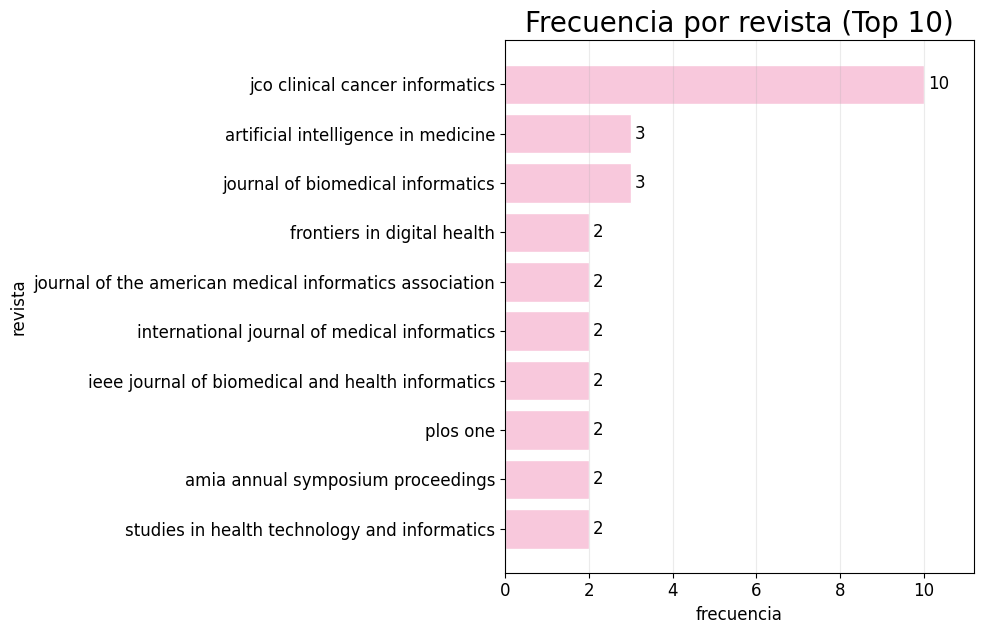

In [ ]:
# @title
conteo_revista = contar_simple(df, "revista").tail(10)
graficar_barras(
    conteo_revista,
    "Frecuencia por revista (Top 10)",
    color=PASTELES[0],
    ylabel="revista"
)

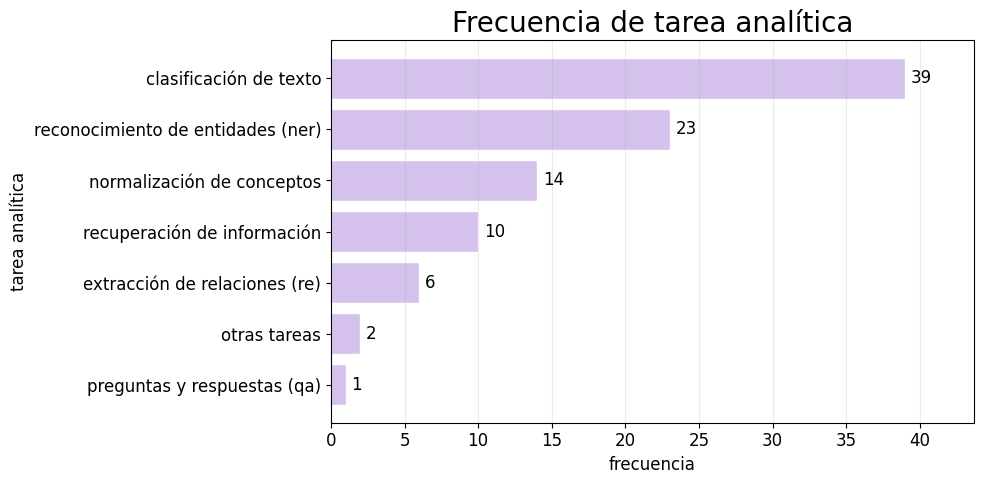

In [ ]:
# @title
conteo_tarea = contar_multivalor(df, "tarea analítica", normalizador=normalizar_tarea)
graficar_barras(
    conteo_tarea,
    "Frecuencia de tarea analítica",
    color=PASTELES[2],
    ylabel="tarea analítica"
)

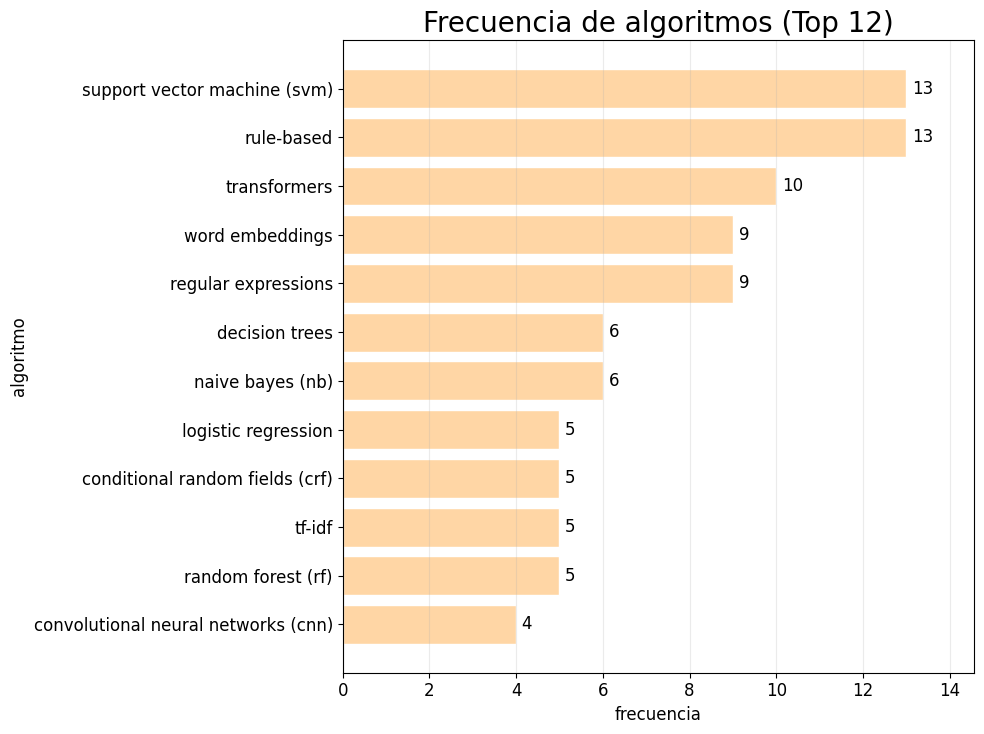

In [ ]:
# @title
conteo_algoritmos = contar_multivalor(
    df,
    ["algoritmos", "otros algoritmos"],
    normalizador=normalizar_algoritmo,
    excluir_otro=True
).tail(12)

graficar_barras(
    conteo_algoritmos,
    "Frecuencia de algoritmos (Top 12)",
    color=PASTELES[1],
    ylabel="algoritmo"
)

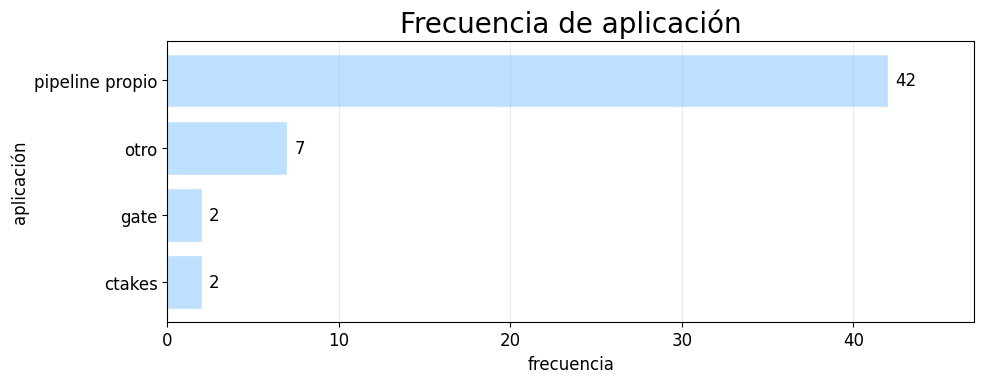

In [ ]:
# @title
conteo_aplicacion = contar_multivalor(df, "aplicación pln clinico", normalizador=normalizar_aplicacion)
graficar_barras(
    conteo_aplicacion,
    "Frecuencia de aplicación",
    color=PASTELES[3],
    ylabel="aplicación"
)

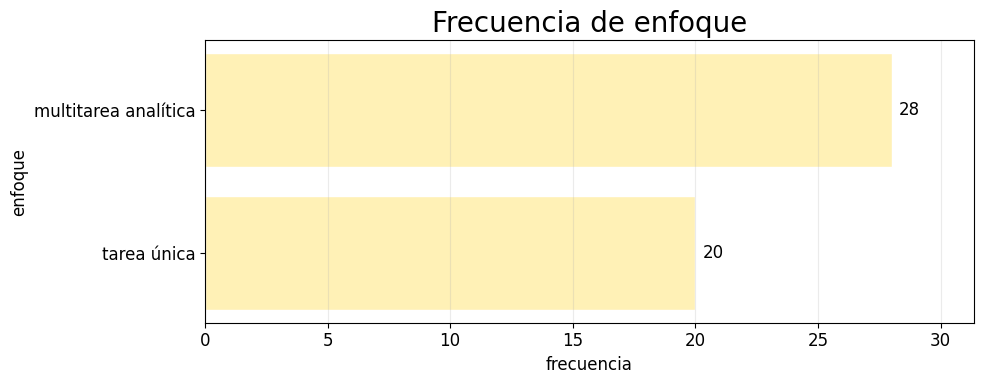

In [ ]:
# @title
conteo_enfoque = contar_simple(df, "enfoque")
graficar_barras(
    conteo_enfoque,
    "Frecuencia de enfoque",
    color=PASTELES[4],
    ylabel="enfoque"
)

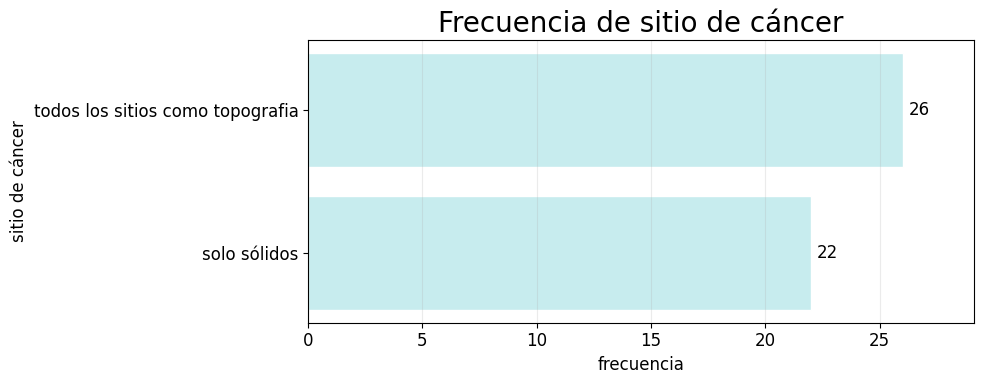

In [ ]:
# @title
conteo_sitio = contar_simple(df, "sitio del cáncer", normalizador=normalizar_sitio_cancer)
graficar_barras(
    conteo_sitio,
    "Frecuencia de sitio de cáncer",
    color=PASTELES[5],
    ylabel="sitio de cáncer"
)

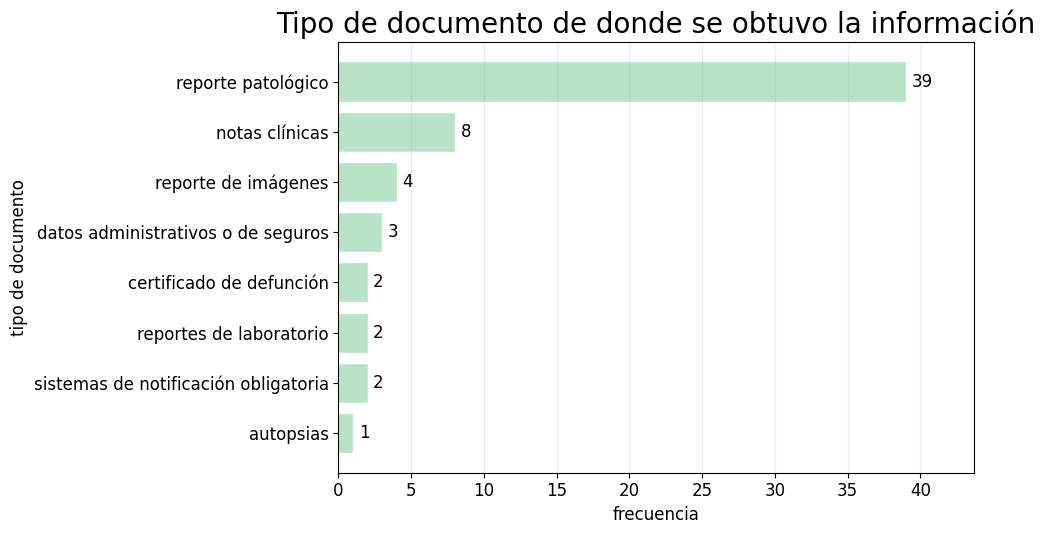

In [ ]:
# @title
conteo_tipo_doc = contar_multivalor(df, "tipo de documento de donde sale el dato", normalizador=normalizar_tipo_documento)
graficar_barras(
    conteo_tipo_doc,
    "Tipo de documento de donde se obtuvo la información",
    color=COLOR_VERDE_IMG,
    ylabel="tipo de documento"
)

Frecuencia de procesos dentro del registro:
extracción de elementos clave                      33
identificación de si un reporte menciona cáncer    20
identificación de la recurrencia o metástasis       6
extracción de información de biomarcadores          5
identificación de la procedencia del caso           4
otros                                               3
seguimiento                                         3
identificar casos reportables                       2
recuperación de información                         1
identificación de primarios múltiples               1


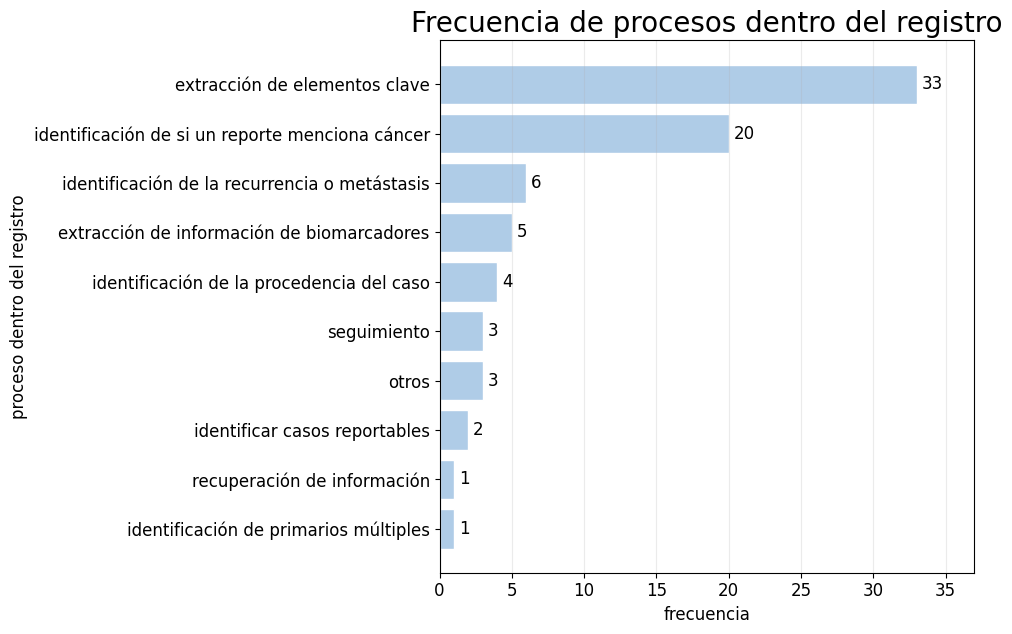

In [ ]:
# @title
conteo_proceso = contar_multivalor(
    df,
    "proceso dentro del registro",
    normalizador=normalizar_proceso
)

print("Frecuencia de procesos dentro del registro:")
print(conteo_proceso.sort_values(ascending=False).to_string())

graficar_barras(
    conteo_proceso,
    "Frecuencia de procesos dentro del registro",
    color=COLOR_AZUL_IMG,
    ylabel="proceso dentro del registro"
)

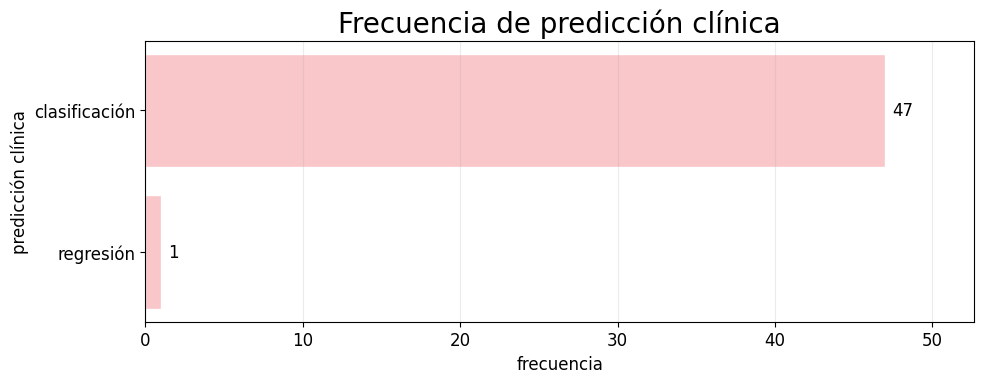

In [ ]:
# @title
conteo_prediccion = contar_simple(df, "predicción clínica", normalizador=normalizar_prediccion)
graficar_barras(
    conteo_prediccion,
    "Frecuencia de predicción clínica",
    color=PASTELES[6],
    ylabel="predicción clínica"
)

## Nube de palabras y boxplot

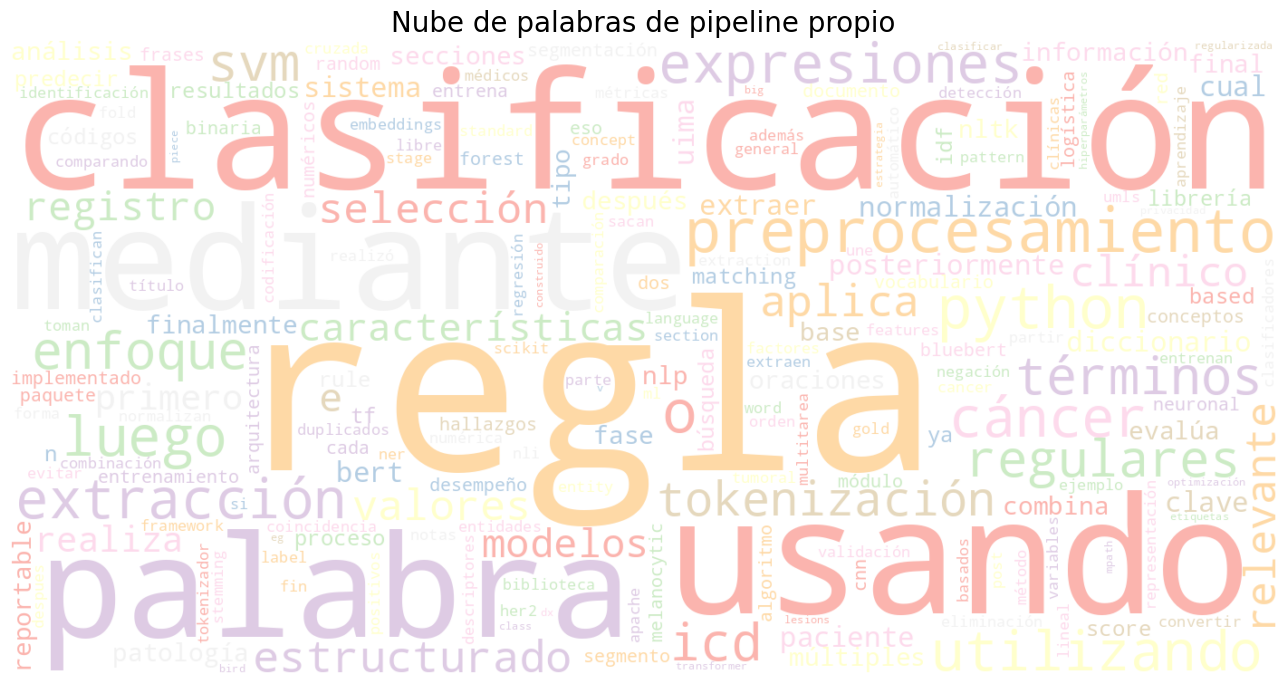

In [ ]:
# @title
texto_pipeline = " ".join(df["pipeline propio, cual?"].dropna().astype(str))

stopwords_es = {
    "de", "la", "el", "en", "y", "a", "para", "con", "del", "los", "las",
    "por", "se", "un", "una", "que", "como", "al", "lo", "su", "más",
    "pipeline", "propio", "modelo", "datos", "texto", "reporte", "reportes",
    "uso", "usan", "aplican", "incluye", "basado", "procesamiento"
}

stopwords = STOPWORDS.union(stopwords_es)

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    colormap="Pastel1",
    stopwords=stopwords,
    collocations=False
).generate(texto_pipeline)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de pipeline propio", fontsize=20)
plt.tight_layout()
plt.show()

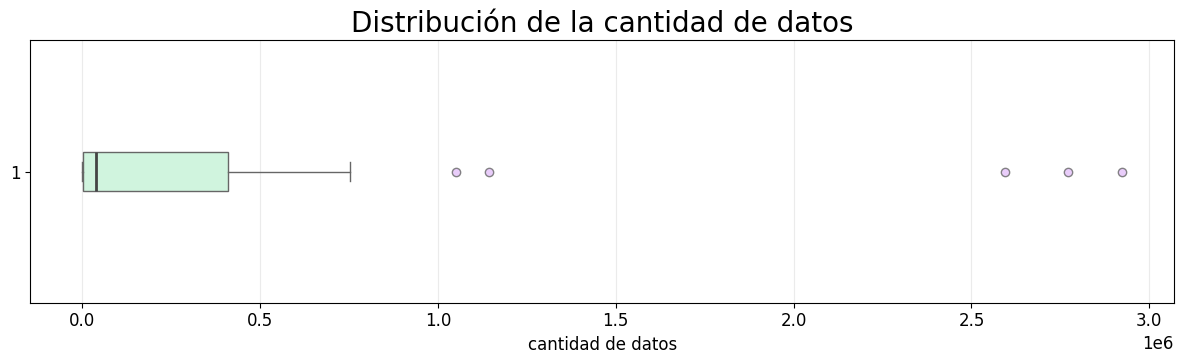

Resumen numérico:
count    4.700000e+01
mean     3.388368e+05
std      7.005636e+05
min      4.570000e+02
25%      1.502500e+03
50%      4.000000e+04
75%      4.111175e+05
max      2.923291e+06
Name: cantidad de datos que se ingresan al modelo, dtype: float64


In [ ]:
# @title
def extraer_numero(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()

    if x in {"no reporta", "nan", ""}:
        return np.nan

    x = x.replace(".", "").replace(",", "")
    numeros = re.findall(r"\d+", x)

    if numeros:
        return float(numeros[0])
    return np.nan

cantidad_datos = df["cantidad de datos que se ingresan al modelo"].apply(extraer_numero).dropna()

plt.figure(figsize=(12, 3.8))
plt.boxplot(
    cantidad_datos,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor=PASTELES[7], edgecolor="#666666"),
    medianprops=dict(color="#444444", linewidth=2),
    whiskerprops=dict(color="#666666"),
    capprops=dict(color="#666666"),
    flierprops=dict(marker="o", markerfacecolor=PASTELES[8], markeredgecolor="#666666", alpha=0.8)
)

plt.title("Distribución de la cantidad de datos", fontsize=20)
plt.xlabel("cantidad de datos")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

print("Resumen numérico:")
print(cantidad_datos.describe())

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


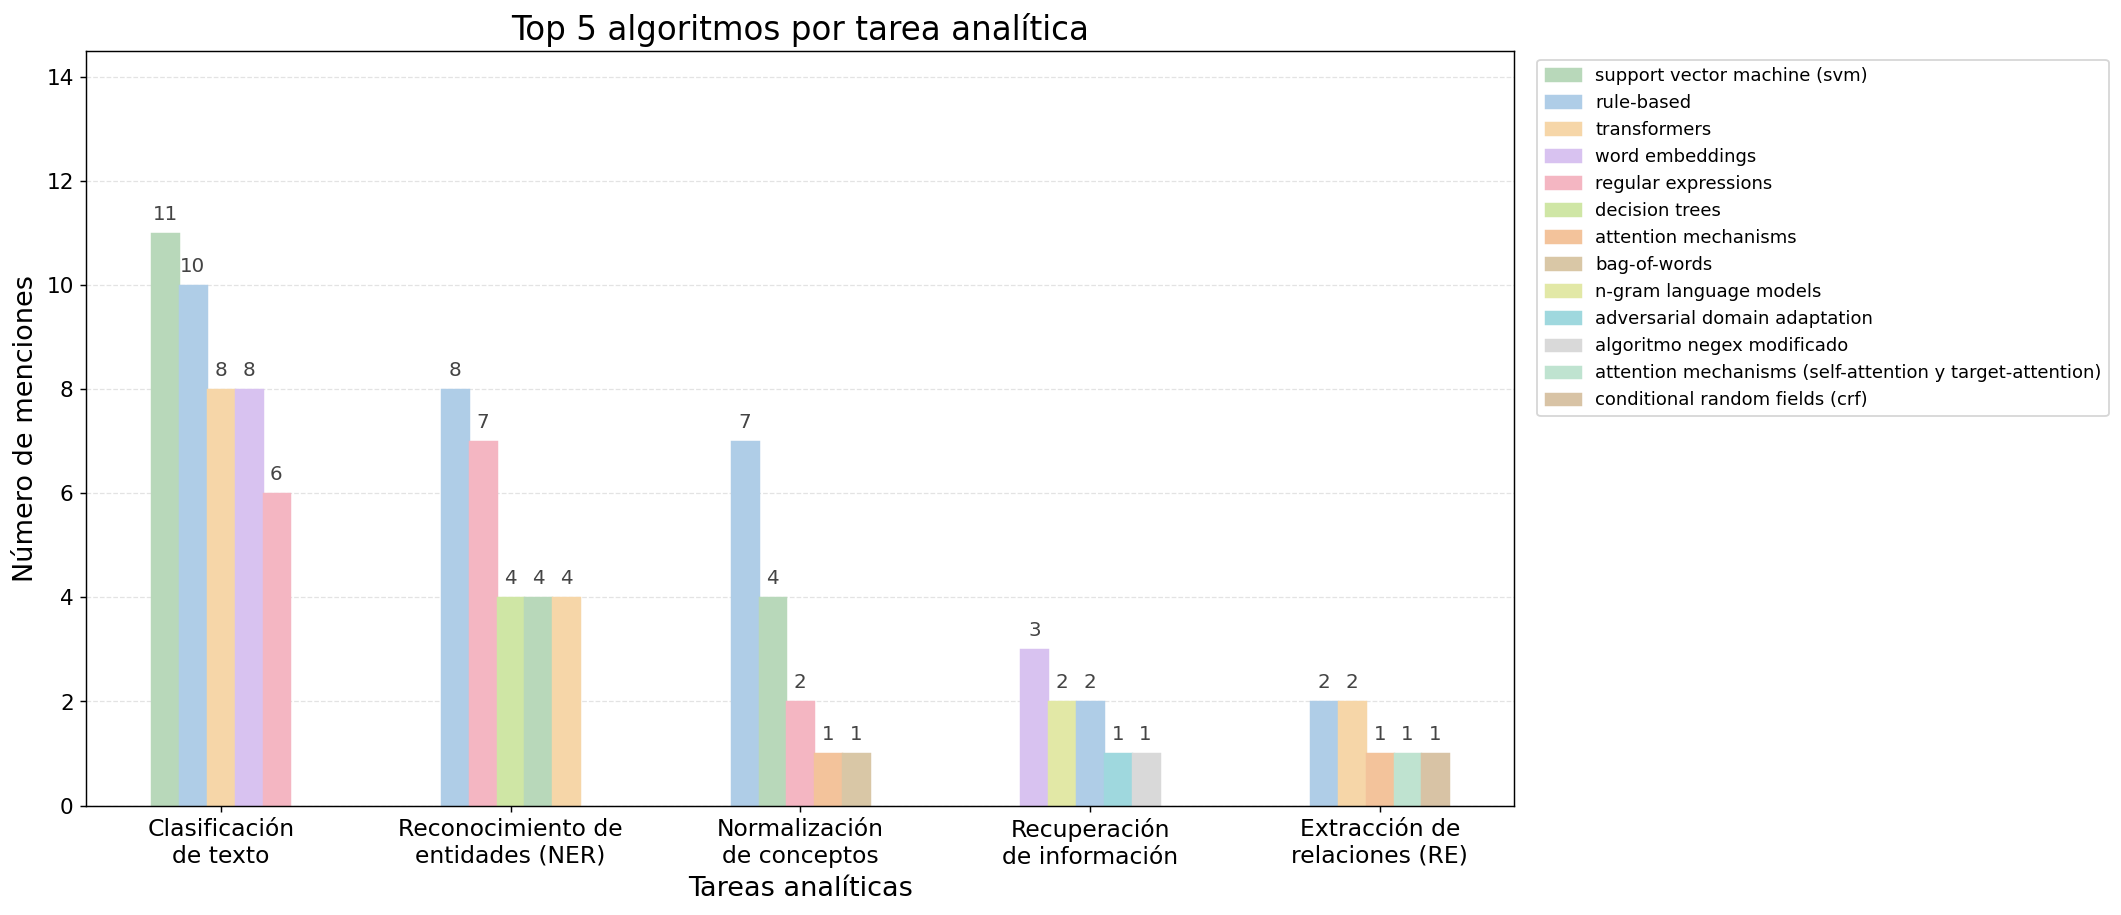

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import Counter, defaultdict
from matplotlib.ticker import MaxNLocator

excel_path = "/content/Articulos.xlsx"

# 1) Leer base
df = pd.read_excel(excel_path, sheet_name="Datos")

# Pasar nombres de columnas a minúsculas
df.columns = df.columns.str.strip().str.lower()

# Pasar a minúsculas todos los valores de texto del dataset
cols_texto = df.select_dtypes(include=["object"]).columns
df[cols_texto] = df[cols_texto].apply(
    lambda col: col.map(lambda x: x.strip().lower() if isinstance(x, str) else x)
)

# Filtrar incluidos
df = df[df["¿se incluye el articulo?"] == "si"].copy()

# 2) Funciones auxiliares
def split_items(s):
    if pd.isna(s):
        return []
    return [p.strip() for p in re.split(r"[;,]", str(s).replace("\n", " ")) if p.strip()]

def canon_task(item):
    t = str(item).strip().lower()
    if "clasificación de texto" in t or "clasificacion de texto" in t:
        return "Clasificación de texto"
    if "reconocimiento de entidades" in t or "(ner)" in t:
        return "Reconocimiento de entidades (NER)"
    if "normalización de conceptos" in t or "normalizacion de conceptos" in t:
        return "Normalización de conceptos"
    if "recuperación de información" in t or "recuperacion de información" in t or "recuperacion de informacion" in t:
        return "Recuperación de información"
    if "extracción de relaciones" in t or "extraccion de relaciones" in t or "(re)" in t:
        return "Extracción de relaciones (RE)"
    return None

# 3) Conteo: un algoritmo cuenta una vez por artículo y por tarea
#    NO se cuenta "otro/otros"
counts = defaultdict(Counter)

for _, row in df.iterrows():
    tasks = {canon_task(t) for t in split_items(row["tarea analítica"])}
    tasks.discard(None)

    algs = set()
    for col in ["algoritmos", "otros algoritmos"]:
        for item in split_items(row[col]):
            item_clean = str(item).strip()
            if item_clean.lower() in {"otro", "otros", "other"}:
                continue
            if item_clean:
                algs.add(item_clean)

    for task in tasks:
        for alg in algs:
            counts[task][alg] += 1

task_order = [
    "Clasificación de texto",
    "Reconocimiento de entidades (NER)",
    "Normalización de conceptos",
    "Recuperación de información",
    "Extracción de relaciones (RE)",
]

# 4) Tabla larga completa
rows = []
for task in task_order:
    for alg, conteo in counts[task].items():
        rows.append([task, alg, conteo])

tabla_completa = pd.DataFrame(rows, columns=["Tarea analítica", "Algoritmo", "Conteo"])
tabla_completa = tabla_completa.sort_values(
    by=["Tarea analítica", "Conteo", "Algoritmo"],
    ascending=[True, False, True]
).reset_index(drop=True)

# 5) Top 5 por tarea
top5 = {}
for task in task_order:
    sub = (
        tabla_completa[tabla_completa["Tarea analítica"] == task]
        .sort_values(["Conteo", "Algoritmo"], ascending=[False, True])
        .head(5)
        .copy()
    )
    top5[task] = list(zip(sub["Algoritmo"], sub["Conteo"]))

# 6) Colores pastel
pastel_palette = [
    "#B8D8BA", "#AFCDE7", "#F6D6A8", "#D8C2F0", "#F4B6C2",
    "#CFE6A5", "#F3C39B", "#D9C7A6", "#E2E8A6", "#9FD8DE",
    "#D9D9D9", "#BFE3D0", "#D8C3A5", "#F7B7A3", "#BFD7B5",
    "#C9B6E4", "#F8C8A8", "#C7E9C0", "#F2C6DE", "#CDE7BE",
    "#B7D3F2", "#E8D9B5", "#D4C4EE", "#B9E3E3", "#F1D4B4"
]

unique_algs = []
for task in task_order:
    for alg, _ in top5[task]:
        if alg not in unique_algs:
            unique_algs.append(alg)

color_map = {alg: pastel_palette[i % len(pastel_palette)] for i, alg in enumerate(unique_algs)}

# 7) Gráfica
fig, ax = plt.subplots(figsize=(16.5, 7.2), dpi=130)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

group_centers = np.arange(len(task_order)) * 2.5
bar_width = 0.24
legend_handles = {}
legend_labels = {}

for i, task in enumerate(task_order):
    pairs = top5[task]
    n = len(pairs)
    offsets = np.linspace(-(n - 1) / 2 * bar_width, (n - 1) / 2 * bar_width, n)

    for offset, (alg, value) in zip(offsets, pairs):
        x = group_centers[i] + offset
        color = color_map[alg]
        bar = ax.bar(
            x,
            value,
            width=bar_width,
            color=color,
            edgecolor=color,
            linewidth=0.8
        )
        ax.text(
            x,
            value + 0.18,
            str(value),
            ha="center",
            va="bottom",
            fontsize=11,
            color="#444444"
        )
        if alg not in legend_handles:
            legend_handles[alg] = bar[0]
            legend_labels[alg] = alg

ax.set_xticks(group_centers)
ax.set_xticklabels(
    [
        "Clasificación\nde texto",
        "Reconocimiento de\nentidades (NER)",
        "Normalización\nde conceptos",
        "Recuperación\nde información",
        "Extracción de\nrelaciones (RE)",
    ],
    fontsize=13
)

ax.set_ylabel("Número de menciones", fontsize=15)
ax.set_xlabel("Tareas analíticas", fontsize=15)
ax.set_title("Top 5 algoritmos por tarea analítica", fontsize=18)

ax.tick_params(axis="y", labelsize=12)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
ax.set_axisbelow(True)
ax.set_ylim(0, max(v for pairs in top5.values() for _, v in pairs) + 3.5)

ax.legend(
    [legend_handles[alg] for alg in unique_algs],
    [legend_labels[alg] for alg in unique_algs],
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    fontsize=10
)

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()

# Opcional: guardar
# plt.savefig("/content/top_5_algoritmos_por_tarea_analitica_pastel.png", dpi=130, bbox_inches="tight", facecolor="white")

Conteo por proceso y tarea analítica:


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,Clasificación de texto,Reconocimiento de entidades (NER),Normalización de conceptos,Recuperación de información,Extracción de relaciones (RE),Otras tareas
Proceso dentro del registro,,,,,,
Extracción de elementos clave,26,17,11,5,5,19
Identificación de si un reporte hace mención de cáncer,20,9,10,5,2,8
Identificación de la recurrencia o metástasis,6,3,3,2,1,2
Demás procesos dentro del registro,17,9,9,5,6,9


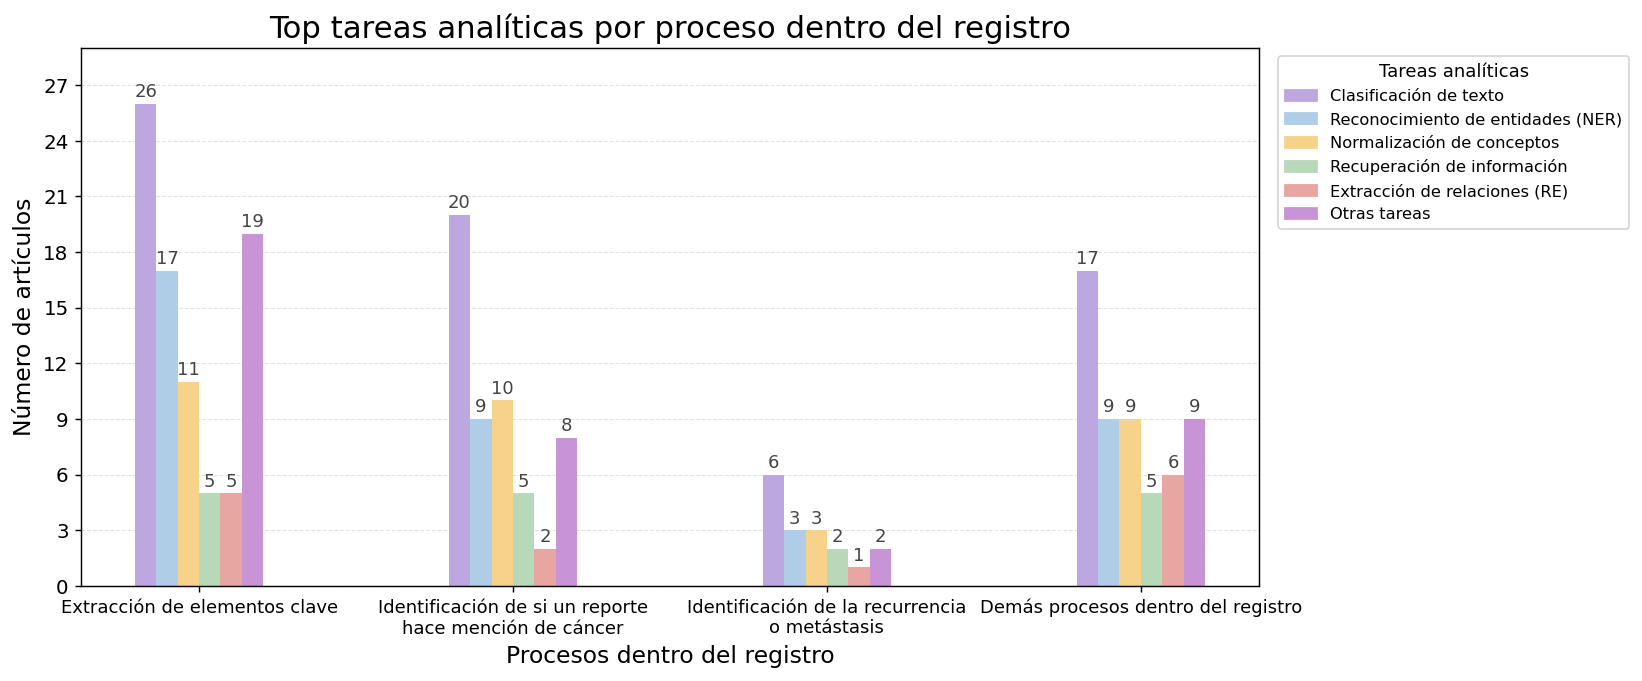

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import Counter, defaultdict
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch

excel_path = "/content/Articulos.xlsx"

# 1) Leer base y filtrar incluidos
df = pd.read_excel(excel_path, sheet_name="Datos")
df = df[df["¿se incluye el articulo?"].astype(str).str.strip().str.lower() == "si"].copy()

# Convertir columnas de texto a minúsculas sin dañar NaN
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].apply(lambda x: x.strip().lower() if isinstance(x, str) else x)

# 2) Funciones auxiliares
def split_commas(s):
    if pd.isna(s):
        return []
    return [p.strip() for p in str(s).replace("\n", " ").split(",") if p.strip()]

def split_other_tasks(s):
    if pd.isna(s):
        return []
    return [p.strip(" .") for p in re.split(r"[;,]", str(s).replace("\n", " ")) if p.strip(" .")]

def norm_task(t):
    tl = str(t).strip().lower()
    if "clasificación de texto" in tl or "clasificacion de texto" in tl:
        return "Clasificación de texto"
    if "reconocimiento de entidades" in tl or "(ner)" in tl:
        return "Reconocimiento de entidades (NER)"
    if "normalización de conceptos" in tl or "normalizacion de conceptos" in tl:
        return "Normalización de conceptos"
    if "recuperación de información" in tl or "recuperacion de información" in tl or "recuperacion de informacion" in tl:
        return "Recuperación de información"
    if "extracción de relaciones" in tl or "extraccion de relaciones" in tl or "(re)" in tl:
        return "Extracción de relaciones (RE)"
    return "Otras tareas"

def norm_process_group(p):
    pl = str(p).strip().lower()
    if "extracción de elementos clave" in pl or "extraccion de elementos clave" in pl:
        return "Extracción de elementos clave"
    if (
        "identificar si un reporte hace mencion de cáncer" in pl
        or "identificar si un reporte hace mención de cáncer" in pl
        or "identificación si un reporte menciona cáncer" in pl
        or "reporte hace mención de cáncer" in pl
        or "reporte hace mencion de cáncer" in pl
        or "reporte menciona cáncer" in pl
    ):
        return "Identificación de si un reporte hace mención de cáncer"
    if "recurrencia o metástasis" in pl or "recurrencia o metastasis" in pl:
        return "Identificación de la recurrencia o metástasis"
    return "Demás procesos dentro del registro"

# 3) Conteo
counts = defaultdict(Counter)

for _, row in df.iterrows():
    process_groups = [norm_process_group(p) for p in split_commas(row["Proceso dentro del registro"])]
    main_tasks = [norm_task(t) for t in split_commas(row["Tarea analítica"])]

    main_unique = list(dict.fromkeys([t for t in main_tasks if t != "Otras tareas"]))

    other_mentions = len(split_other_tasks(row.get("Otras tareas analíticas", None))) + sum(
        1 for t in main_tasks if t == "Otras tareas"
    )

    for proc in process_groups:
        for task in main_unique:
            counts[proc][task] += 1
        counts[proc]["Otras tareas"] += other_mentions

process_order = [
    "Extracción de elementos clave",
    "Identificación de si un reporte hace mención de cáncer",
    "Identificación de la recurrencia o metástasis",
    "Demás procesos dentro del registro",
]

task_order = [
    "Clasificación de texto",
    "Reconocimiento de entidades (NER)",
    "Normalización de conceptos",
    "Recuperación de información",
    "Extracción de relaciones (RE)",
    "Otras tareas",
]

data = {
    proc: {task: counts[proc][task] for task in task_order}
    for proc in process_order
}

# 4) Mostrar tabla de conteo
count_table = pd.DataFrame(data).T[task_order]
count_table.index.name = "Proceso dentro del registro"
print("Conteo por proceso y tarea analítica:")
display(count_table)

# 5) Colores pastel
pastel_colors = {
    "Clasificación de texto": "#BDA7E0",
    "Reconocimiento de entidades (NER)": "#AFCDE7",
    "Normalización de conceptos": "#F6D28B",
    "Recuperación de información": "#B8D8BA",
    "Extracción de relaciones (RE)": "#E7A6A1",
    "Otras tareas": "#C894D6",
}

# 6) Gráfica
fig, ax = plt.subplots(figsize=(12.8, 5.4), dpi=130)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

x_centers = np.arange(len(process_order)) * 2.2
bar_width = 0.15

for xc, proc in zip(x_centers, process_order):
    nonzero_tasks = [t for t in task_order if data[proc][t] > 0]
    n = len(nonzero_tasks)

    left = xc - (n * bar_width) / 2
    xs = [left + i * bar_width for i in range(n)]

    for x, task in zip(xs, nonzero_tasks):
        v = data[proc][task]
        ax.bar(
            x,
            v,
            width=bar_width,
            color=pastel_colors[task],
            edgecolor=pastel_colors[task],
            linewidth=0,
            align="edge",
        )
        ax.text(
            x + bar_width / 2,
            v + 0.15,
            str(v),
            ha="center",
            va="bottom",
            fontsize=10,
            color="#444444",
        )

ax.set_title("Top tareas analíticas por proceso dentro del registro", fontsize=17)
ax.set_xlabel("Procesos dentro del registro", fontsize=13)
ax.set_ylabel("Número de artículos", fontsize=13)

ax.set_xticks(x_centers)
ax.set_xticklabels(
    [
        "Extracción de elementos clave",
        "Identificación de si un reporte\nhace mención de cáncer",
        "Identificación de la recurrencia\no metástasis",
        "Demás procesos dentro del registro",
    ],
    fontsize=10
)

ax.tick_params(axis="y", labelsize=11)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylim(0, max(max(vals.values()) for vals in data.values()) + 3)
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(True)

legend_handles = [Patch(facecolor=pastel_colors[t], edgecolor=pastel_colors[t], label=t) for t in task_order]
ax.legend(
    handles=legend_handles,
    title="Tareas analíticas",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    fontsize=9,
    title_fontsize=10,
)

plt.tight_layout()
plt.show()

# Opcional: guardar
# plt.savefig("/content/top_tareas_analiticas_por_proceso_dentro_del_registro.png", dpi=130, facecolor="white", bbox_inches="tight")

mapa

,País,Frecuencia
0,Estados Unidos,22
1,Australia,4
2,Italia,3
3,Colombia,3
4,Canadá,3
5,Chile,2
6,Taiwán,2
7,Sudáfrica,2
8,Brasil,1
9,Alemania,1


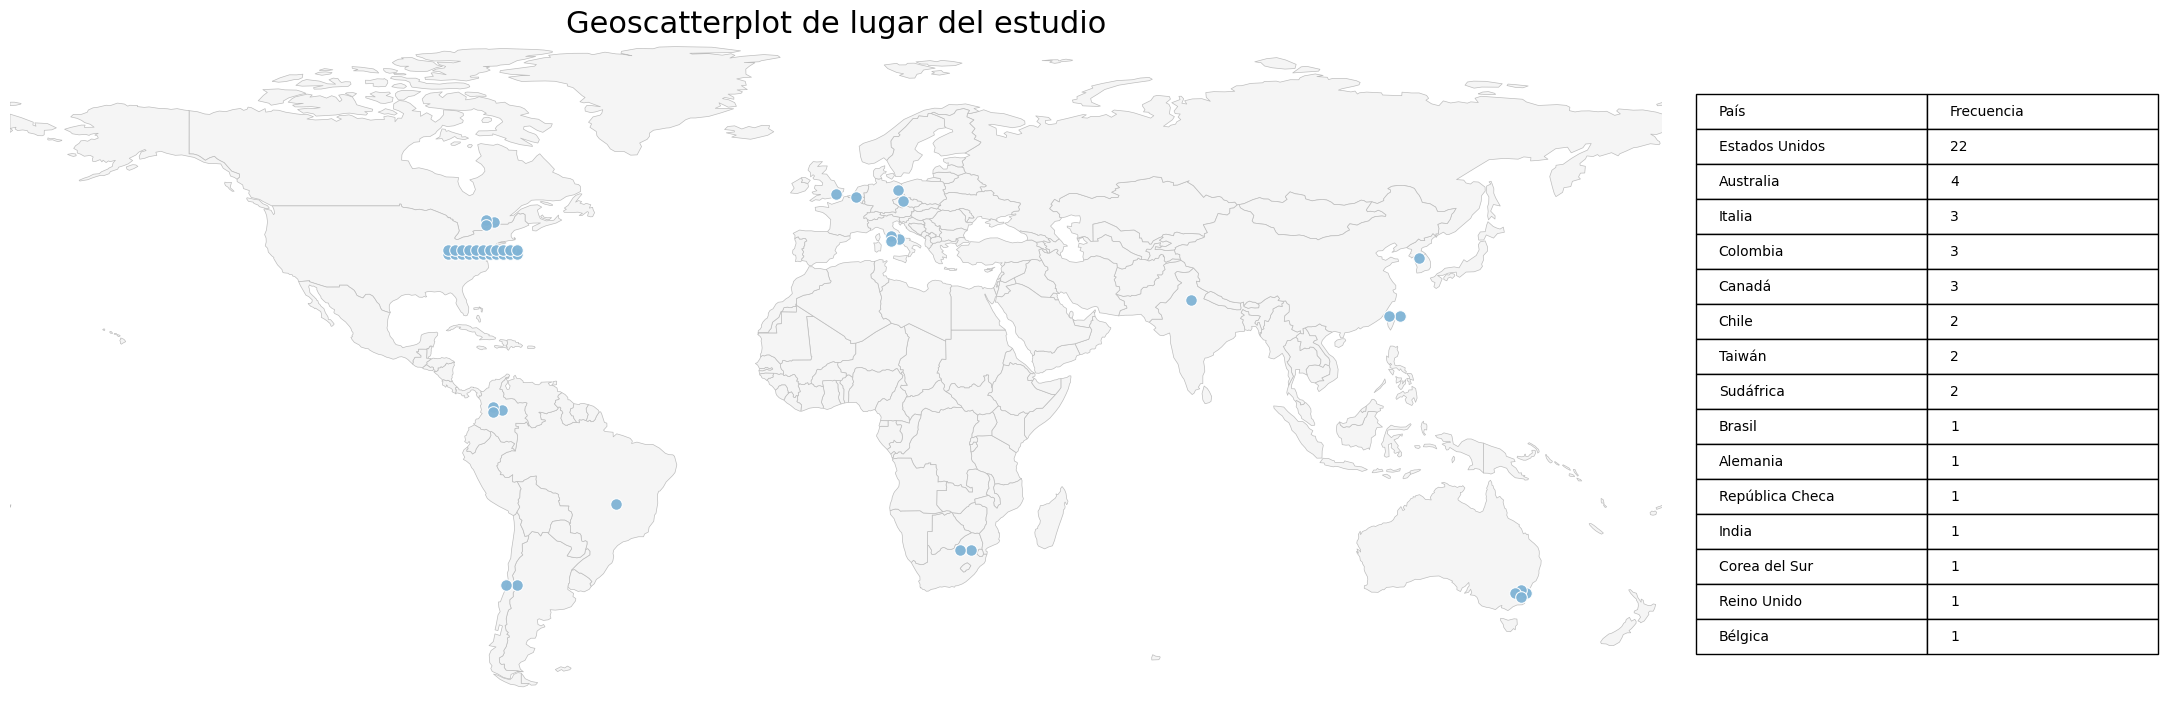

In [ ]:
# @title
!pip -q install geopandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import re
import unicodedata
from IPython.display import display

if "df" not in globals():
    excel_path = "/content/Articulos.xlsx"
    df = pd.read_excel(excel_path, sheet_name="Datos")
    df.columns = df.columns.str.strip().str.lower() # Ensure columns are lowercase if df is freshly loaded
    cols_texto = df.select_dtypes(include=["object"]).columns
    df[cols_texto] = df[cols_texto].apply(lambda col: col.map(lambda x: x.strip().lower() if isinstance(x, str) else x))
    if "¿se incluye el articulo?" in df.columns:
        df = df[df["¿se incluye el articulo?"] == "si"].copy()
else:
    # If df already exists, ensure its columns are lowercase for this block
    df.columns = df.columns.str.lower()

def norm_txt(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    x = re.sub(r"\s+", " ", x)
    return x

def split_items(s):
    if pd.isna(s):
        return []
    return [p.strip() for p in re.split(r"[;,|\n]+", str(s)) if p.strip()]

col_candidates = [
    "lugar de estudio", # Changed to lowercase
    "lugar estudio",
    "territorio del articulo",
    "territorio del artículo",
    "pais del estudio",
    "país del estudio",
    "pais",
    "país",
    "country",
    "study location",
    "ubicacion del estudio",
    "ubicación del estudio"
]

col_lugar = next((c for c in col_candidates if c in df.columns), None)
if col_lugar is None:
    raise ValueError(f"No encontré la columna de lugar del estudio. Revisé: {col_candidates}. Columnas disponibles: {df.columns.tolist()}")

alias_to_country = {
    "colombia": "Colombia",
    "chile": "Chile",
    "argentina": "Argentina",
    "brasil": "Brasil",
    "brazil": "Brasil",
    "mexico": "México",
    "peru": "Perú",
    "ecuador": "Ecuador",
    "uruguay": "Uruguay",
    "paraguay": "Paraguay",
    "bolivia": "Bolivia",
    "venezuela": "Venezuela",
    "costa rica": "Costa Rica",
    "panama": "Panamá",
    "guatemala": "Guatemala",
    "honduras": "Honduras",
    "el salvador": "El Salvador",
    "nicaragua": "Nicaragua",
    "cuba": "Cuba",
    "republica dominicana": "República Dominicana",
    "dominican republic": "República Dominicana",
    "puerto rico": "Puerto Rico",
    "estados unidos": "Estados Unidos",
    "eeuu": "Estados Unidos",
    "eua": "Estados Unidos",
    "usa": "Estados Unidos",
    "u.s.a.": "Estados Unidos",
    "u.s.": "Estados Unidos",
    "united states": "Estados Unidos",
    "canada": "Canadá",
    "united kingdom": "Reino Unido",
    "uk": "Reino Unido",
    "u.k.": "Reino Unido",
    "reino unido": "Reino Unido",
    "england": "Reino Unido",
    "scotland": "Reino Unido",
    "wales": "Reino Unido",
    "great britain": "Reino Unido",
    "ireland": "Irlanda",
    "irlanda": "Irlanda",
    "netherlands": "Países Bajos",
    "the netherlands": "Países Bajos",
    "paises bajos": "Países Bajos",
    "paises bajos": "Países Bajos",
    "holland": "Países Bajos",
    "belgium": "Bélgica",
    "belgica": "Bélgica",
    "france": "Francia",
    "francia": "Francia",
    "germany": "Alemania",
    "alemania": "Alemania",
    "spain": "España",
    "espana": "España",
    "italy": "Italia",
    "italia": "Italia",
    "portugal": "Portugal",
    "switzerland": "Suiza",
    "suiza": "Suiza",
    "austria": "Austria",
    "sweden": "Suecia",
    "suecia": "Suecia",
    "norway": "Noruega",
    "noruega": "Noruega",
    "finland": "Finlandia",
    "finlandia": "Finlandia",
    "denmark": "Dinamarca",
    "dinamarca": "Dinamarca",
    "poland": "Polonia",
    "polonia": "Polonia",
    "czech republic": "República Checa",
    "republica checa": "República Checa",
    "hungary": "Hungría",
    "hungria": "Hungría",
    "romania": "Rumania",
    "rumania": "Rumania",
    "greece": "Grecia",
    "grecia": "Grecia",
    "turkey": "Turquía",
    "turquia": "Turquía",
    "israel": "Israel",
    "saudi arabia": "Arabia Saudita",
    "arabia saudita": "Arabia Saudita",
    "united arab emirates": "Emiratos Árabes Unidos",
    "emiratos arabes unidos": "Emiratos Árabes Unidos",
    "qatar": "Qatar",
    "egypt": "Egipto",
    "egipto": "Egipto",
    "south africa": "Sudáfrica",
    "sudafrica": "Sudáfrica",
    "nigeria": "Nigeria",
    "kenya": "Kenia",
    "morocco": "Marruecos",
    "marocco": "Marruecos",
    "marruecos": "Marruecos",
    "india": "India",
    "china": "China",
    "japan": "Japón",
    "japon": "Japón",
    "south korea": "Corea del Sur",
    "korea": "Corea del Sur",
    "korea, south": "Corea del Sur",
    "corea del sur": "Corea del Sur",
    "taiwan": "Taiwán",
    "thailand": "Tailandia",
    "singapore": "Singapur",
    "malaysia": "Malasia",
    "indonesia": "Indonesia",
    "philippines": "Filipinas",
    "filipinas": "Filipinas",
    "pakistan": "Pakistán",
    "australia": "Australia",
    "new zealand": "Nueva Zelanda",
    "nueva zelanda": "Nueva Zelanda"
}

capital_coords = {
    "Colombia": (4.7110, -74.0721),
    "Chile": (-33.4489, -70.6693),
    "Argentina": (-34.6037, -58.3816),
    "Brasil": (-15.7939, -47.8828),
    "México": (19.4326, -99.1332),
    "Perú": (-12.0464, -77.0428),
    "Ecuador": (-0.1807, -78.4678),
    "Uruguay": (-34.9011, -56.1645),
    "Paraguay": (-25.2637, -57.5759),
    "Bolivia": (-16.4897, -68.1193),
    "Venezuela": (10.4806, -66.9036),
    "Costa Rica": (9.9281, -84.0907),
    "Panamá": (8.9824, -79.5199),
    "Guatemala": (14.6349, -90.5069),
    "Honduras": (14.0723, -87.1921),
    "El Salvador": (13.6929, -89.2182),
    "Nicaragua": (12.1140, -86.2362),
    "Cuba": (23.1136, -82.3666),
    "República Dominicana": (18.4861, -69.9312),
    "Puerto Rico": (18.4655, -66.1057),
    "Estados Unidos": (38.9072, -77.0369),
    "Canadá": (45.4215, -75.6972),
    "Reino Unido": (51.5074, -0.1278),
    "Irlanda": (53.3498, -6.2603),
    "Países Bajos": (52.3676, 4.9041),
    "Bélgica": (50.8503, 4.3517),
    "Francia": (48.8566, 2.3522),
    "Alemania": (52.5200, 13.4050),
    "España": (40.4168, -3.7038),
    "Italia": (41.9028, 12.4964),
    "Portugal": (38.7223, -9.1393),
    "Suiza": (46.9480, 7.4474),
    "Austria": (48.2082, 16.3738),
    "Suecia": (59.3293, 18.0686),
    "Noruega": (59.9139, 10.7522),
    "Finlandia": (60.1699, 24.9384),
    "Dinamarca": (55.6761, 12.5683),
    "Polonia": (52.2297, 21.0122),
    "República Checa": (50.0755, 14.4378),
    "Hungría": (47.4979, 19.0402),
    "Rumania": (44.4268, 26.1025),
    "Grecia": (37.9838, 23.7275),
    "Turquía": (39.9334, 32.8597),
    "Israel": (31.7683, 35.2137),
    "Arabia Saudita": (24.7136, 46.6753),
    "Emiratos Árabes Unidos": (24.4539, 54.3773),
    "Qatar": (25.2854, 51.5310),
    "Egipto": (30.0444, 31.2357),
    "Sudáfrica": (-25.7479, 28.2293),
    "Nigeria": (9.0765, 7.3986),
    "Kenia": (-1.2921, 36.8219),
    "Marruecos": (34.0209, -6.8416),
    "India": (28.6139, 77.2090),
    "China": (39.9042, 116.4074),
    "Japón": (35.6762, 139.6503),
    "Corea del Sur": (37.5665, 126.9780),
    "Taiwán": (25.0330, 121.5654),
    "Tailandia": (13.7563, 100.5018),
    "Singapur": (1.3521, 103.8198),
    "Malasia": (3.1390, 101.6869),
    "Indonesia": (-6.2088, 106.8456),
    "Filipinas": (14.5995, 120.9842),
    "Pakistán": (33.6844, 73.0479),
    "Australia": (-35.2809, 149.1300),
    "Nueva Zelanda": (-41.2866, 174.7756)
}

valores_pais = []
for valor in df[col_lugar].dropna():
    items = split_items(valor)
    if not items:
        items = [valor]
    canonicos = []
    for item in items:
        key = norm_txt(item)
        if key in alias_to_country:
            canonicos.append(alias_to_country[key])
    canonicos = list(dict.fromkeys(canonicos))
    valores_pais.extend(canonicos)

conteo_pais = pd.Series(valores_pais).value_counts().rename_axis("País").reset_index(name="Frecuencia")
display(conteo_pais)

registros = []
faltantes = []

for _, row in conteo_pais.iterrows():
    pais = row["País"]
    n = int(row["Frecuencia"])
    if pais not in capital_coords:
        faltantes.append(pais)
        continue
    lat0, lon0 = capital_coords[pais]

    if pais == "Estados Unidos":
        num_points = n
        # Arrange in a 2x11 grid
        points_per_row = 11
        num_rows = (num_points + points_per_row - 1) // points_per_row # Ceiling division

        # Adjust these values as needed for visual separation
        horizontal_spacing = 1.5 # degrees longitude
        vertical_spacing = 0.8 # degrees latitude

        us_offsets = []
        for i in range(num_points):
            row_idx = i // points_per_row
            col_idx = i % points_per_row

            dlon = (col_idx - (points_per_row - 1) / 2) * horizontal_spacing
            dlat = (row_idx - (num_rows - 1) / 2) * vertical_spacing
            us_offsets.append((dlat, dlon))
        offsets = us_offsets
    elif n == 1:
        offsets = [(0.0, 0.0)]
    else:
        angulos = np.linspace(0, 2 * np.pi, n, endpoint=False)
        radio_lon = 1.2
        radio_lat = 0.7
        offsets = [(radio_lat * np.sin(a), radio_lon * np.cos(a)) for a in angulos]

    for dlat, dlon in offsets:
        registros.append({"País": pais, "lat": lat0 + dlat, "lon": lon0 + dlon})

puntos = pd.DataFrame(registros)

world = gpd.read_file("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson")

fig, ax = plt.subplots(figsize=(22, 11))
world.plot(ax=ax, color="#f5f5f5", edgecolor="#bdbdbd", linewidth=0.5)
ax.scatter(
    puntos["lon"],
    puntos["lat"],
    s=70,
    color="#7fb3d5",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.95
)

ax.set_title("Geoscatterplot de lugar del estudio", fontsize=22)
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.axis("off")

tabla_leyenda = conteo_pais.copy()
tabla = ax.table(
    cellText=tabla_leyenda.values,
    colLabels=tabla_leyenda.columns,
    cellLoc="left",
    colLoc="left",
    bbox=[1.02, 0.08, 0.28, 0.84]
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)

plt.tight_layout()
plt.show()

if faltantes:
    print("No se pudieron ubicar automáticamente estos países:", ", ".join(faltantes))